In [1]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
import pyvinecopulib as pv

from scipy.stats import norm

from GPDFlow_S import S_mGPD_NF, ConditionalMaskedAffineFlow, ActNormConditional, ConditionalNormalizingFlow
import Common_Functions as cf
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats


Using device: cuda


In [25]:
# --- 5-fold cross-validation setup (mirrors Exchange_rate_application.ipynb) ---
import importlib
import cv_utils
importlib.reload(cv_utils)
from cv_utils import (make_folds, run_cv_gpdflow_likelihood,
                      simulate_1_mgpd, run_simulation_study_1,
                      summarize_simulation_study_1)


#### Define a GPDFlow

In [3]:
dir_out = "/home/pgrad2/2448355h/My_PhD_Project/01_Output/GPDFlow/"

dim = 25


#### Find a suitable threshold for the simulated data

In [5]:
# ── Marginal parameters — defined once at 25-dim, sliced to :dim below ───────
sigma_full  = np.array([0.5, 1.2, 1.0, 1.5, 0.8] * 10)   # shape (50,)
gamma_full  = np.array([-0.1, 0.2, 0.0, 0.1, 0.3] * 10)  # shape (50,)

n_samples = 1000

# ── Generator T: independent reverse-exponential components ─────────────────
#   f_j(v_j) = alpha_j * exp{ alpha_j (v_j + beta_j) },   v_j in (-inf, -beta_j)
# Here alpha_1 = ... = alpha_d = alpha  and  beta_1 = ... = beta_d = 0, so each
#   T_j = log(U_j) / alpha ,  U_j ~ Unif(0, 1)  i.i.d. across j
#       = -W_j ,  W_j ~ Exp(rate = alpha).
# (Same generator as cf.sim_revexp_T_mgpd, whose scale a_j = 1 / alpha_j and
#  whose location is the same beta_j.)
alpha = 1.0    # alpha_1 = ... = alpha_d
beta  = 0.0    # beta_1  = ... = beta_d

np.random.seed(42)
torch.manual_seed(42)

U_gen     = np.random.uniform(0.0, 1.0, size=(n_samples, dim))
T_samples = np.log(U_gen) / alpha - beta   # (n_samples, dim); every column < -beta

# ── Visualise T (2-D only) ─────────────────────────────────────────────────
if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(T_samples[:, 0], T_samples[:, 1], alpha=0.3, s=3, color='indianred')
    ax.set_xlabel('$T_1$');  ax.set_ylabel('$T_2$')
    ax.set_title('Independent reverse-exponential generator $T$ (2D)')
    plt.tight_layout();  plt.show()

# ── Visualise the normalizing-flow base distribution U ~ N(0, I) (2-D only) ──
if dim == 2:
    U_samples = np.random.randn(n_samples, dim)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(U_samples[:, 0], U_samples[:, 1], alpha=0.3, s=3, color='gray')
    ax.set_xlabel('$U_1$');  ax.set_ylabel('$U_2$')
    ax.set_title('Standard Gaussian base distribution $U$ (2D)')
    plt.tight_layout();  plt.show()

# ── Standardised mGPD:  Z = E + T − max(T) ─────────────────────────────────
T_t   = torch.tensor(T_samples, dtype=torch.float32)
T_max = torch.max(T_t, dim=1, keepdim=True).values
T_cen = T_t - T_max   # S = T − max(T): the generator margin used by the S-representation

E = torch.empty(n_samples).exponential_(1.0).unsqueeze(1)
Z = E + T_cen   # standardised mGPD samples (y-space)

# ── Visualise standardised mGPD Z (2-D only) ───────────────────────────────
if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(Z[:, 0].numpy(), Z[:, 1].numpy(), alpha=0.2, s=3, color='steelblue')
    ax.set_xlabel('$Z_1$');  ax.set_ylabel('$Z_2$')
    ax.set_title('Standardised mGPD samples $Z$ (y-space, 2D)')
    plt.tight_layout();  plt.show()

# ── Marginal parameters (slice 25-dim full vectors to :dim) ────────────────
sigma = torch.tensor(sigma_full[:dim], dtype=torch.float32)
gamma = torch.tensor(gamma_full[:dim], dtype=torch.float32)
print(f"sigma = {sigma.numpy().round(3)}")
print(f"gamma = {gamma.numpy().round(3)}")

# ── Forward transform:  X_ij = σ_j·Z_ij               if γ_j = 0
#                        X_ij = σ_j/γ_j·(exp(γ_j·Z_ij) − 1)  if γ_j ≠ 0 ──
zero_mask = (gamma == 0)
X = torch.where(
    zero_mask,
    sigma * Z,
    (sigma / gamma) * (torch.exp(gamma * Z) - 1),
)

samples_origin = X.detach().numpy()
print(f"\nGenerated {n_samples} mGPD samples  |  shape: {samples_origin.shape}")

# ── Visualise transformed mGPD X (2-D only) ────────────────────────────────
if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(samples_origin[:, 0], samples_origin[:, 1], alpha=0.2, s=3, color='indianred')
    ax.set_xlabel('$X_1$');  ax.set_ylabel('$X_2$')
    ax.set_title('Transformed mGPD samples $X$ (x-space, 2D)')
    plt.tight_layout();  plt.show()

# ── Verify:  pairwise χ of this mGPD  ==  1 − 1/(1 + 2·alpha)  ──────────────
# For the reverse-exponential generator with equal alpha across margins, the
# mGPD pairwise upper tail-dependence coefficient has the closed form
#       χ = 1 − 1/(1 + 2·alpha)
# (the alpha_1 = alpha_2 special case of cf.chi_theorical). χ is the q→1 limit
# of χ(q), so we estimate χ(q) on the standardised scale Z from a large
# independent batch and check the estimates sit at the theoretical value.
chi_theo = 1.0 - 1.0 / (1.0 + 2.0 * alpha)
print(f"\ntheoretical χ = 1 - 1/(1 + 2·alpha) = {chi_theo:.4f}   "
      f"(cf.chi_theorical(alpha, alpha) = {cf.chi_theorical(alpha, alpha):.4f})")

n_big = 200_000
np.random.seed(0)
T_big = np.log(np.random.uniform(0.0, 1.0, size=(n_big, dim))) / alpha - beta
S_big = T_big - T_big.max(axis=1, keepdims=True)
E_big = np.random.exponential(1.0, n_big)[:, None]
Z_big = E_big + S_big

print(f"\n{'q':>7} | {'mean empirical χ(q)':>20} | {'1 - 1/(1+2·alpha)':>17}")
for q in [0.90, 0.95, 0.98, 0.99, 0.995]:
    chi_mat  = cf.pairwise_chi_from_data(Z_big, q)
    off_diag = chi_mat[~np.eye(dim, dtype=bool)]
    print(f"{q:>7.3f} | {off_diag.mean():>20.4f} | {chi_theo:>17.4f}")


sigma = [0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
gamma = [-0.1  0.2  0.   0.1  0.3 -0.1  0.2  0.   0.1  0.3 -0.1  0.2  0.   0.1
  0.3 -0.1  0.2  0.   0.1  0.3 -0.1  0.2  0.   0.1  0.3]

Generated 1000 mGPD samples  |  shape: (1000, 25)

theoretical χ = 1 - 1/(1 + 2·alpha) = 0.6667   (cf.chi_theorical(alpha, alpha) = 0.6667)



      q |  mean empirical χ(q) | 1 - 1/(1+2·alpha)
  0.900 |               0.6648 |            0.6667
  0.950 |               0.6651 |            0.6667
  0.980 |               0.6638 |            0.6667
  0.990 |               0.6640 |            0.6667
  0.995 |               0.6576 |            0.6667


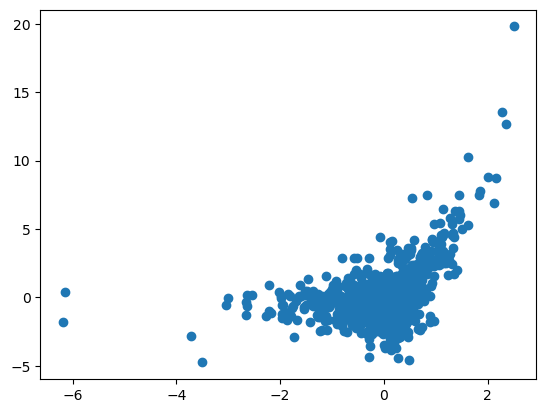

In [6]:
# thres = np.quantile(samples_origin, 0.99,axis=0)

# cond = (samples_origin[:,0] > thres[0] ) | (samples_origin[:,1] > thres[1] ) 
# samples = samples_origin[cond,:]

# thres = thres.reshape(1,-1)
# samples = samples - thres

samples = samples_origin
plt.scatter(samples[:,0],samples[:,1] )


In [4]:
# Partition the full simulated sample into 5 CV folds (same idiom as FX).
folds = make_folds(len(samples), n_splits=5, seed=1234)
print('fold val sizes:', [len(v) for _, v in folds])

# No POT threshold in the simulation -> `+ thres` inside cv_utils is a no-op and
# the model draws stay on the same raw scale as `samples_origin`.
thres = np.zeros((1, dim))

NameError: name 'samples' is not defined

In [ ]:
SMOKE      = False                 # True -> fast top-to-bottom check
EPOCHS_LIK = 5 if SMOKE else 500
SIM_MULT   = 30                    # simulated rows per fold = SIM_MULT * |fold k|
CHI_Q      = 0.95                  # level for pairwise chi (no thresholding -> p_sim = CHI_Q)

LIK_CFG = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=200,
    seed=1234,
)
# --- Likelihood-based GPDFlow, 5-fold cross-validation --------------------
# Fold k: train on the other 4 folds, early-stop on fold k (patience 100 on the
# validation NLL), then draw SIM_MULT * |fold k| observations from the fold-k
# model. cv_utils keeps the 5 out-of-fold blocks SEPARATE (`samples_simu_folds`,
# raw scale) and returns the fold-mean marginal estimates.
# init_from_gpd=True warm-starts each fold's margins from a per-fold univariate
# GPD fit of the exceedance data; False -> cold start at sigma=1, gamma=0.
cv_like = run_cv_gpdflow_likelihood(
    samples, folds, device, thres,
    epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
    patience=100, init_from_gpd=False, **LIK_CFG,
)

print('per-fold best val NLL :', np.round(cv_like['best_vals'], 4))
print('per-fold best epoch   :', [h['best_epoch'] for h in cv_like['hist']])

sigma_hat = cv_like['sigma_hat']               # length-dim, CV fold mean
gamma_hat = cv_like['gamma_hat']               # length-dim, CV fold mean
sigma_hat_folds = cv_like['sigma_hat_folds']   # n_folds x dim (across-fold spread)
gamma_hat_folds = cv_like['gamma_hat_folds']
print('fold-mean sigma_hat :', np.round(sigma_hat, 3))
print('fold-mean gamma_hat :', np.round(gamma_hat, 3))


In [21]:
# --- CV outputs: average estimated chi + average marginal parameters -----
sigma_true = sigma_full[:dim]
gamma_true = gamma_full[:dim]

# theoretical pairwise chi: constant 1 - 1/(1 + 2*alpha) off the diagonal
chi_theo = cf.chi_theorical(alpha, alpha)
chi_true = np.full((dim, dim), chi_theo)
np.fill_diagonal(chi_true, 1.0)
idx = np.triu_indices(dim, k=1)

# "average estimated chi" = mean over the 5 fold models of each fold's rank-based
# pairwise chi (folds NOT pooled: a pool of 5 flows is a mixture, not an mGPD).
def cv_pairwise_chi(fold_blocks, p):
    return np.mean([cf.pairwise_chi_from_data(b, p=p) for b in fold_blocks], axis=0)

chi_hat = cv_pairwise_chi(cv_like['samples_simu_folds'], CHI_Q)   # dim x dim, CV average

# --- RMSE vs the known simulation truth ---------------------------------
rmse_sigma = cf.rmse_gamma(sigma_hat, sigma_true)      # plain RMSE
rmse_gamma_val = cf.rmse_gamma(gamma_hat, gamma_true)  # plain RMSE
rmse_chi_val = cf.rmse_chi(chi_hat[idx], chi_true[idx])

print(f'average estimated chi (off-diag mean) : {chi_hat[idx].mean():.4f}   (true {chi_theo:.4f})')
print(f'average sigma_hat : {np.round(sigma_hat, 3)}')
print(f'average gamma_hat : {np.round(gamma_hat, 3)}')
print()
print(f'RMSE chi   : {rmse_chi_val:.4f}')
print(f'RMSE sigma : {rmse_sigma:.4f}')
print(f'RMSE gamma : {rmse_gamma_val:.4f}')
print(f'TDE  chi   : {cf.tde_chi(chi_hat, chi_true):.4f}')

average estimated chi (off-diag mean) : 0.6613   (true 0.6667)
average sigma_hat : [0.586 1.092 0.986 1.257 0.857 0.58  1.192 1.052 1.252 0.857 0.566 1.116
 1.003 1.147 0.876 0.601 1.154 1.011 1.128 0.888 0.572 1.094 0.877 1.224
 0.873]
average gamma_hat : [-0.16   0.216  0.013  0.154  0.258 -0.192  0.206 -0.013  0.144  0.242
 -0.163  0.24   0.022  0.144  0.242 -0.209  0.211 -0.018  0.168  0.217
 -0.174  0.205  0.02   0.192  0.21 ]

RMSE chi   : 0.0257
RMSE sigma : 0.1509
RMSE gamma : 0.0567
TDE  chi   : 0.0207


#### Monte Carlo simulation study: bias and variance of the CV estimators

`run_simulation_study_1` repeats the data-generating process above and refits the
likelihood-based GPDFlow by 5-fold CV on each generated sample. Every round it stores the
**aggregated CV estimators** &mdash; the fold-mean marginal parameters $\hat\sigma$, $\hat\gamma$
and the fold-mean rank-based pairwise $\hat\chi$ (at level `CHI_Q`). `summarize_simulation_study_1`
then reports, per margin / per pair, the Monte Carlo bias $\;\overline{\hat\theta}-\theta\;$ and
variance $\;\widehat{\operatorname{Var}}(\hat\theta)\;$ against the known simulation truth
($\sigma$, $\gamma$ from cell&nbsp;5 and $\chi = 1-1/(1+2\alpha)$).

Defaults match the current notebook setting (`n_samples=1000`, `dim=25`, `alpha=1`, `EPOCHS_LIK`,
`SIM_MULT`, `LIK_CFG`); pass partial `sim_kwargs` / `model_kwargs` dicts to override individual
knobs. Runtime &asymp; `n_sim` &times; one 5-fold CV.

Set `init_from_gpd=True` to warm-start each fold's GPDFlow marginal parameters from a per-margin
univariate GPD fit (`scipy.stats.genpareto.fit(col, floc=0)`) of that fold's training exceedances,
instead of the default cold start at $\sigma=1$, $\gamma=0$.


In [5]:
# ── Marginal parameters — defined once at 25-dim, sliced to :dim below ───────
sigma_full  = np.array([0.5, 1.2, 1.0, 1.5, 0.8] * 10)   # shape (50,)
gamma_full  = np.array([-0.1, 0.2, 0.0, 0.1, 0.3] * 10)  # shape (50,)

n_samples = 1000

# ── Generator T: independent reverse-exponential components ─────────────────
#   f_j(v_j) = alpha_j * exp{ alpha_j (v_j + beta_j) },   v_j in (-inf, -beta_j)
# Here alpha_1 = ... = alpha_d = alpha  and  beta_1 = ... = beta_d = 0, so each
#   T_j = log(U_j) / alpha ,  U_j ~ Unif(0, 1)  i.i.d. across j
#       = -W_j ,  W_j ~ Exp(rate = alpha).
# (Same generator as cf.sim_revexp_T_mgpd, whose scale a_j = 1 / alpha_j and
#  whose location is the same beta_j.)
alpha = 1.0    # alpha_1 = ... = alpha_d
beta  = 0.0    # beta_1  = ... = beta_d


SMOKE      = False                 # True -> fast top-to-bottom check
EPOCHS_LIK = 5 if SMOKE else 500
SIM_MULT   = 30                    # simulated rows per fold = SIM_MULT * |fold k|
CHI_Q      = 0.95                  # level for pairwise chi (no thresholding -> p_sim = CHI_Q)


In [6]:
# --- Repeat DGP + CV fit over N rounds, then Monte Carlo RMSE vs truth -------
N_SIM = 10

LIK_CFG_1 = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=0,
    seed=1234,
)

study1 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1, summary1 = summarize_simulation_study_1(study1)

print(f'RMSE sigma : {summary_df1.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df1.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df1.loc["chi", "rmse"]:.4f}')


RMSE sigma : 0.2101
RMSE gamma : 0.0831
RMSE chi   : 0.0320


In [26]:
# --- Same config as study1_2, but warm-start the GPDFlow margins from a
#     per-fold univariate GPD fit of the exceedance data (init_from_gpd=True).
#     Compare the RMSE triple against study1_2 (cold start: sigma=1, gamma=0).
N_SIM = 10

study1_gpd = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1),
    init_from_gpd=True,
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_gpd, summary1_gpd = summarize_simulation_study_1(study1_gpd)

print('init_from_gpd=True  vs  study1_2 (cold start)')
print(f'RMSE sigma : {summary_df1_gpd.loc["sigma", "rmse"]:.4f}   '
      f'(cold {summary_df1_gpd.loc["sigma", "rmse"]:.4f})')
print(f'RMSE gamma : {summary_df1_gpd.loc["gamma", "rmse"]:.4f}   '
      f'(cold {summary_df1_gpd.loc["gamma", "rmse"]:.4f})')
print(f'RMSE chi   : {summary_df1_gpd.loc["chi", "rmse"]:.4f}   '
      f'(cold {summary_df1_gpd.loc["chi", "rmse"]:.4f})')

init_from_gpd=True  vs  study1_2 (cold start)
RMSE sigma : 0.0782   (cold 0.0782)
RMSE gamma : 0.0461   (cold 0.0461)
RMSE chi   : 0.0226   (cold 0.0226)


In [11]:
N_SIM = 10

LIK_CFG_1_1 = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=50,
    seed=1234,
)

study1_1 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1_1),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_1, summary1_1 = summarize_simulation_study_1(study1_1)

print(f'RMSE sigma : {summary_df1_1.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df1_1.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df1_1.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1681
RMSE gamma : 0.0650
RMSE chi   : 0.0255


In [29]:
# --- Same config as study1_2, but warm-start the GPDFlow margins from a
#     per-fold univariate GPD fit of the exceedance data (init_from_gpd=True).
#     Compare the RMSE triple against study1_2 (cold start: sigma=1, gamma=0).
N_SIM = 10

study1_1gpd = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1_1),
    init_from_gpd=True,
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_1gpd, summary1_1gpd = summarize_simulation_study_1(study1_1gpd)

print('init_from_gpd=True  vs  study1_2 (cold start)')
print(f'RMSE sigma : {summary_df1_1gpd.loc["sigma", "rmse"]:.4f}   '
      f'(cold {summary_df1_1.loc["sigma", "rmse"]:.4f})')
print(f'RMSE gamma : {summary_df1_1gpd.loc["gamma", "rmse"]:.4f}   '
      f'(cold {summary_df1_1.loc["gamma", "rmse"]:.4f})')
print(f'RMSE chi   : {summary_df1_1gpd.loc["chi", "rmse"]:.4f}   '
      f'(cold {summary_df1.loc["chi", "rmse"]:.4f})')

init_from_gpd=True  vs  study1_2 (cold start)
RMSE sigma : 0.0778   (cold 0.1681)
RMSE gamma : 0.0489   (cold 0.0650)
RMSE chi   : 0.0229   (cold 0.0320)


In [12]:
N_SIM = 10

LIK_CFG_1_2 = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=100,
    seed=1234,
)

study1_2 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1_2),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_2, summary1_2 = summarize_simulation_study_1(study1_2)

print(f'RMSE sigma : {summary_df1_2.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df1_2.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df1_2.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1488
RMSE gamma : 0.0592
RMSE chi   : 0.0238


In [30]:
# --- Same config as study1_2, but warm-start the GPDFlow margins from a
#     per-fold univariate GPD fit of the exceedance data (init_from_gpd=True).
#     Compare the RMSE triple against study1_2 (cold start: sigma=1, gamma=0).
N_SIM = 10

study1_2gpd = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1_2),
    init_from_gpd=True,
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_2gpd, summary1_2gpd = summarize_simulation_study_1(study1_2gpd)

print('init_from_gpd=True  vs  study1_2 (cold start)')
print(f'RMSE sigma : {summary_df1_2gpd.loc["sigma", "rmse"]:.4f}   '
      f'(cold {summary_df1_2.loc["sigma", "rmse"]:.4f})')
print(f'RMSE gamma : {summary_df1_2gpd.loc["gamma", "rmse"]:.4f}   '
      f'(cold {summary_df1_2.loc["gamma", "rmse"]:.4f})')
print(f'RMSE chi   : {summary_df1_2gpd.loc["chi", "rmse"]:.4f}   '
      f'(cold {summary_df2.loc["chi", "rmse"]:.4f})')


init_from_gpd=True  vs  study1_2 (cold start)
RMSE sigma : 0.0749   (cold 0.1488)
RMSE gamma : 0.0483   (cold 0.0592)
RMSE chi   : 0.0228   (cold 0.0339)


In [ ]:
N_SIM = 10

LIK_CFG_1_3 = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=200,
    seed=1234,
)

study1_3 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1_3),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_3, summary1_3 = summarize_simulation_study_1(study1_3)

print(f'RMSE sigma : {summary_df1_3.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df1_3.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df1_3.loc["chi", "rmse"]:.4f}')

In [14]:
print(f'RMSE sigma : {summary_df1_3.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df1_3.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df1_3.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1274
RMSE gamma : 0.0589
RMSE chi   : 0.0226


In [15]:
N_SIM = 10

LIK_CFG_1_4 = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=500,
    seed=1234,
)

study1_4 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1_4),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_4, summary1_4 = summarize_simulation_study_1(study1_4)

print(f'RMSE sigma : {summary_df1_4.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df1_4.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df1_4.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1051
RMSE gamma : 0.0603
RMSE chi   : 0.0217


In [27]:
N_SIM = 10

study1_4gpd = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_1_4),
    init_from_gpd=True,
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df1_4gpd, summary1_4gpd = summarize_simulation_study_1(study1_4gpd)

print('init_from_gpd=True  vs  study1_4 (cold start)')
print(f'RMSE sigma : {summary_df1_4gpd.loc["sigma", "rmse"]:.4f}   '
      f'(cold {summary_df1_4gpd.loc["sigma", "rmse"]:.4f})')
print(f'RMSE gamma : {summary_df1_4gpd.loc["gamma", "rmse"]:.4f}   '
      f'(cold {summary_df1_4gpd.loc["gamma", "rmse"]:.4f})')
print(f'RMSE chi   : {summary_df1_4gpd.loc["chi", "rmse"]:.4f}   '
      f'(cold {summary_df1_4gpd.loc["chi", "rmse"]:.4f})')

init_from_gpd=True  vs  study1_4 (cold start)
RMSE sigma : 0.0751   (cold 0.0751)
RMSE gamma : 0.0494   (cold 0.0494)
RMSE chi   : 0.0223   (cold 0.0223)


In [28]:
print('init_from_gpd=True  vs  study1_4 (cold start)')
print(f'RMSE sigma : {summary_df1_4gpd.loc["sigma", "rmse"]:.4f}   '
      f'(cold {summary_df1_4.loc["sigma", "rmse"]:.4f})')
print(f'RMSE gamma : {summary_df1_4gpd.loc["gamma", "rmse"]:.4f}   '
      f'(cold {summary_df1_4.loc["gamma", "rmse"]:.4f})')
print(f'RMSE chi   : {summary_df1_4gpd.loc["chi", "rmse"]:.4f}   '
      f'(cold {summary_df1_4.loc["chi", "rmse"]:.4f})')

init_from_gpd=True  vs  study1_4 (cold start)
RMSE sigma : 0.0751   (cold 0.1051)
RMSE gamma : 0.0494   (cold 0.0603)
RMSE chi   : 0.0223   (cold 0.0217)


In [7]:
# --- Repeat DGP + CV fit over N rounds, then Monte Carlo RMSE vs truth -------
N_SIM = 10

LIK_CFG_2 = dict(
    num_layers=6, latent_size_factor=4,
    penalty_lambda=1e4, marg_lambda=0,
    seed=1234,
)

study2 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_2),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df2, summary2 = summarize_simulation_study_1(study2)

print(f'RMSE sigma : {summary_df2.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df2.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df2.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.2264
RMSE gamma : 0.0991
RMSE chi   : 0.0339


In [16]:
N_SIM = 10

LIK_CFG_2_1 = dict(
    num_layers=6, latent_size_factor=4,
    penalty_lambda=1e4, marg_lambda=50,
    seed=1234,
)

study2_1 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_2_1),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df2_1, summary2_1 = summarize_simulation_study_1(study2_1)

print(f'RMSE sigma : {summary_df2_1.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df2_1.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df2_1.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1759
RMSE gamma : 0.0740
RMSE chi   : 0.0279


In [17]:
N_SIM = 10

LIK_CFG_2_2 = dict(
    num_layers=6, latent_size_factor=4,
    penalty_lambda=1e4, marg_lambda=100,
    seed=1234,
)

study2_2 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_2_2),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df2_2, summary2_2 = summarize_simulation_study_1(study2_2)

print(f'RMSE sigma : {summary_df2_2.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df2_2.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df2_2.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1586
RMSE gamma : 0.0638
RMSE chi   : 0.0255


In [18]:
N_SIM = 10

LIK_CFG_2_3 = dict(
    num_layers=6, latent_size_factor=4,
    penalty_lambda=1e4, marg_lambda=200,
    seed=1234,
)

study2_3 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_2_3),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df2_3, summary2_3 = summarize_simulation_study_1(study2_3)

print(f'RMSE sigma : {summary_df2_3.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df2_3.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df2_3.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1380
RMSE gamma : 0.0675
RMSE chi   : 0.0231


In [19]:
N_SIM = 10

LIK_CFG_2_4 = dict(
    num_layers=6, latent_size_factor=4,
    penalty_lambda=1e4, marg_lambda=500,
    seed=1234,
)

study2_4 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_2_4),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df2_4, summary2_4 = summarize_simulation_study_1(study2_4)

print(f'RMSE sigma : {summary_df2_4.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df2_4.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df2_4.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1098
RMSE gamma : 0.0642
RMSE chi   : 0.0218


In [8]:
# --- Repeat DGP + CV fit over N rounds, then Monte Carlo RMSE vs truth -------
N_SIM = 10

LIK_CFG_3 = dict(
    num_layers=8, latent_size_factor=5,
    penalty_lambda=1e4, marg_lambda=0,
    seed=1234,
)

study3 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_3),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df3, summary3 = summarize_simulation_study_1(study3)

print(f'RMSE sigma : {summary_df3.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df3.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df3.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.2282
RMSE gamma : 0.1062
RMSE chi   : 0.0346


In [21]:
# --- Repeat DGP + CV fit over N rounds, then Monte Carlo RMSE vs truth -------
N_SIM = 10

LIK_CFG_3_1 = dict(
    num_layers=8, latent_size_factor=5,
    penalty_lambda=1e4, marg_lambda=50,
    seed=1234,
)

study3_1 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_3_1),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df3_1, summary3_1 = summarize_simulation_study_1(study3_1)

print(f'RMSE sigma : {summary_df3_1.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df3_1.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df3_1.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1792
RMSE gamma : 0.0744
RMSE chi   : 0.0281


In [22]:
# --- Repeat DGP + CV fit over N rounds, then Monte Carlo RMSE vs truth -------
N_SIM = 10

LIK_CFG_3_2 = dict(
    num_layers=8, latent_size_factor=5,
    penalty_lambda=1e4, marg_lambda=100,
    seed=1234,
)

study3_2 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_3_2),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df3_2, summary3_2 = summarize_simulation_study_1(study3_2)

print(f'RMSE sigma : {summary_df3_2.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df3_2.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df3_2.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1610
RMSE gamma : 0.0704
RMSE chi   : 0.0260


In [23]:
# --- Repeat DGP + CV fit over N rounds, then Monte Carlo RMSE vs truth -------
N_SIM = 10

LIK_CFG_3_3 = dict(
    num_layers=8, latent_size_factor=5,
    penalty_lambda=1e4, marg_lambda=200,
    seed=1234,
)

study3_3 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_3_3),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df3_3, summary3_3 = summarize_simulation_study_1(study3_3)

print(f'RMSE sigma : {summary_df3_3.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df3_3.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df3_3.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1389
RMSE gamma : 0.0666
RMSE chi   : 0.0246


In [24]:
# --- Repeat DGP + CV fit over N rounds, then Monte Carlo RMSE vs truth -------
N_SIM = 10

LIK_CFG_3_4 = dict(
    num_layers=8, latent_size_factor=5,
    penalty_lambda=1e4, marg_lambda=500,
    seed=1234,
)

study3_4 = run_simulation_study_1(
    n_sim=N_SIM,
    device=device,
    base_seed=42,                                  # round r uses DGP seed 42 + r
    sim_kwargs=dict(n_samples=n_samples, dim=20, alpha=alpha, beta=beta),
    model_kwargs=dict(epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
                      patience=100, **LIK_CFG_3_4),
    n_splits=5, fold_seed=1234, chi_q=CHI_Q,
    verbose=False,
)

summary_df3_4, summary3_4 = summarize_simulation_study_1(study3_4)

print(f'RMSE sigma : {summary_df3_4.loc["sigma", "rmse"]:.4f}')
print(f'RMSE gamma : {summary_df3_4.loc["gamma", "rmse"]:.4f}')
print(f'RMSE chi   : {summary_df3_4.loc["chi", "rmse"]:.4f}')

RMSE sigma : 0.1083
RMSE gamma : 0.0674
RMSE chi   : 0.0227


In [ ]:
# --- Visualise the Monte Carlo bias / variance ------------------------------
sns.set(style='ticks', font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
margins = np.arange(study1['sigma_true'].size)

for ax, name in [(axes[0], 'sigma'), (axes[1], 'gamma')]:
    bias = summary1[f'{name}_bias']
    sd = np.sqrt(summary1[f'{name}_variance'])
    ax.axhline(0.0, color='0.6', lw=1)
    ax.errorbar(margins, bias, yerr=sd, fmt='o', capsize=3, color='darkslategray')
    ax.set_xlabel('margin $j$')
    ax.set_ylabel(rf'$\overline{{\hat\{name}}}_j - \{name}_j$  ($\pm$ SD)')
    ax.set_title(rf'$\{name}$: bias $\pm$ std across {study1["config"]["n_sim"]} rounds')

axes[2].hist(study1['chi_hat_offdiag_mean'], bins=12, color='darkgoldenrod', alpha=0.8)
axes[2].axvline(study1['chi_true'], color='k', ls='--', label=r'true $\chi$')
axes[2].set_xlabel(r'per-round off-diagonal mean $\hat\chi$')
axes[2].set_ylabel('count')
axes[2].set_title(r'$\hat\chi$ across rounds')
axes[2].legend()

plt.tight_layout()
plt.show()
